In [ ]:
from google.colab import drive
drive.mount('/content/drive')

! pip install numpyro
# ! pip install jax_cosmo
! pip install arviz
! pip install jaxopt
! pip install corner
! pip install emcee

import sys
sys.path.append('/content/drive/MyDrive/SchwarMAX')


import pickle

import jax
import jaxopt
import jax.nn as jnn
import jax.numpy as jnp
from functools import partial

import time as tt
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18

import os
import corner
import numpy as np
import multiprocessing as mp

from potentials import *
from integrants import *
from utils import *

from potentials import NFW_acceleration
from densities import MiyamotoNagai_density

from CylindricalSpline import get_phi_m, get_acc

import numpyro
from numpyro_model import numpyro_model

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.9/370.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.3 MB/s eta 0:00:00


In [ ]:
@jax.jit
def logl(params, dict_data):


    params_halo_pot = {
        'logM': params['logM_halo'],
        'Rs':10 ** params['logRs_halo'],
        'a':1.0,
        'b':1.0,
        'c':1.0,
        'x_origin':0.0,
        'y_origin':0.0,
        'z_origin':0.0,
        'dirx':0.0,
        'diry':0.0,
        'dirz':1.0
    }

    params_disk_rho = {
        'logM': params['logM_disk'],
        'Rs': 10 ** params['logRs_disk'],
        'Hs': 10 ** params['logHs_disk'],
        'x_origin': 0.0,
        'y_origin': 0.0,
        'z_origin': 0.0,
        'dirx': 0.0,
        'diry': 0.0,
        'dirz': 1.0
    }

    vr_binned, sigmavr_binned, vphi_binned, sigmavphi_binned, vz_binned, sigmavz_binned = model(params_halo_pot, params_disk_rho, dict_data)
    vr_binned = jnp.where(jnp.isnan(vr_binned), 0.0, vr_binned)
    sigmavr_binned = jnp.where(jnp.isnan(sigmavr_binned), 0.0, sigmavr_binned)
    vphi_binned = jnp.where(jnp.isnan(vphi_binned), 0.0, vphi_binned)
    sigmavphi_binned = jnp.where(jnp.isnan(sigmavphi_binned), 0.0, sigmavphi_binned)
    vz_binned = jnp.where(jnp.isnan(vz_binned), 0.0, vz_binned)
    sigmavz_binned = jnp.where(jnp.isnan(sigmavz_binned), 0.0, sigmavz_binned)

    frac_err = 0.1

    log_likelihood = 0
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['vz_data_binned'] - vr_binned)**2) / (frac_err * dict_data['vz_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['vphi_data_binned'] - vphi_binned)**2) / (frac_err * dict_data['vphi_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['vz_data_binned'] - vz_binned)**2) / (frac_err * dict_data['vz_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['sigmavr_data_binned'] - sigmavr_binned)**2) / (frac_err * dict_data['sigmavr_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['sigmavphi_data_binned'] - sigmavphi_binned)**2) / (frac_err * dict_data['sigmavphi_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['sigmavz_data_binned'] - sigmavz_binned)**2) / (frac_err * dict_data['sigmavz_data_binned'] + 1e-3) )

    return log_likelihood

@jax.jit
def model(params_halo_pot, params_disk_rho, dict_data):

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    time, xv = jax.vmap(integrate_leapfrog_traj, in_axes=(0, None, None, None, None, None))(dict_data['w0'], acc_fn, n_steps, dt, initial_time, unroll)
    density_model = jax.vmap(histogram3d)(xv[:, :, :3], None)

    A = density_model.reshape(len(xv), -1).T.astype(jnp.float32)/n_steps
    y = dict_data['density_data'].reshape(-1).astype(jnp.float32)
    sig = 0.01 * y + 1 # jnp.sqrt(y + 1.0).astype(jnp.float32)  # Poisson noise + 1.0 floor

    weights = solve_lbfgs_softplus(A, y, sig, l2=1e-3, maxiter=300)

    weights_binned = histogram3d(xv[:, :, :3].reshape(-1, 3), jnp.repeat(weights, n_steps).ravel())

    r_model    = jnp.linalg.norm(xv[:, :, :2], axis=-1)
    vr_model   = (xv[:, :, 0] * xv[:, :, 3] + xv[:, :, 1] * xv[:, :, 4]) / r_model
    vr_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vr_model*weights[:, None]).ravel())/(weights_binned+EPSILON)
    vr2_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vr_model**2 * weights[:, None]).ravel())/(weights_binned+EPSILON)
    sigmavr_binned = jnp.sqrt(jnp.clip(vr2_binned - vr_binned**2, a_min=0.0))

    vphi = -(-xv[:, :, 1] * xv[:, :, 3] + xv[:, :, 0] * xv[:, :, 4]) / r_model
    vphi_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vphi*weights[:, None]).ravel())/(weights_binned+EPSILON)
    vphi2_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vphi**2 * weights[:, None]).ravel())/(weights_binned+EPSILON)
    sigmavphi_binned = jnp.sqrt(jnp.clip(vphi2_binned - vphi_binned**2, a_min=0.0))

    vz_binned = histogram3d(xv[:, :, :3].reshape(-1, 3), (xv[:, :, 5]*weights[:, None]).ravel())/(weights_binned+EPSILON)
    vz2_binned = histogram3d(xv[:, :, :3].reshape(-1, 3), (xv[:, :, 5]**2 * weights[:, None]).ravel())/(weights_binned+EPSILON)
    sigmavz_binned = jnp.sqrt(jnp.clip(vz2_binned - vz_binned**2, a_min=0.0))

    return vr_binned, sigmavr_binned, vphi_binned, sigmavphi_binned, vz_binned, sigmavz_binned

@jax.jit
def _nll_z(z, A, y, sig, l2):
    x = jnn.softplus(z)  # strictly positive
    r = (A @ x - y) / sig
    return 0.5 * jnp.dot(r, r) + 0.5 * l2 * jnp.dot(x, x)
_nll_z = jax.value_and_grad(_nll_z)

@jax.jit
def solve_lbfgs_softplus(A, y, sigma, l2=1e-3, maxiter=500, tol=1e-6):
    z0 = jnp.zeros(A.shape[1], A.dtype)
    solver = jaxopt.LBFGS(fun=_nll_z, value_and_grad=True, maxiter=maxiter, tol=tol, implicit_diff=True)
    res = solver.run(z0, A, y, sigma, l2)
    x_hat = jnn.softplus(res.params)
    return x_hat

In [ ]:


@jax.jit
def logl(params, dict_data):


    params_halo_pot = {
        'logM': params['logM_halo'],
        'Rs':10 ** params['logRs_halo'],
        'a':1.0,
        'b':1.0,
        'c':1.0,
        'x_origin':0.0,
        'y_origin':0.0,
        'z_origin':0.0,
        'dirx':0.0,
        'diry':0.0,
        'dirz':1.0
    }

    params_disk_rho = {
        'logM': params['logM_disk'],
        'Rs': 10 ** params['logRs_disk'],
        'Hs': 10 ** params['logHs_disk'],
        'x_origin': 0.0,
        'y_origin': 0.0,
        'z_origin': 0.0,
        'dirx': 0.0,
        'diry': 0.0,
        'dirz': 1.0
    }

    vr_binned, sigmavr_binned, vphi_binned, sigmavphi_binned, vz_binned, sigmavz_binned = model(params_halo_pot, params_disk_rho, dict_data)
    vr_binned = jnp.where(jnp.isnan(vr_binned), 0.0, vr_binned)
    sigmavr_binned = jnp.where(jnp.isnan(sigmavr_binned), 0.0, sigmavr_binned)
    vphi_binned = jnp.where(jnp.isnan(vphi_binned), 0.0, vphi_binned)
    sigmavphi_binned = jnp.where(jnp.isnan(sigmavphi_binned), 0.0, sigmavphi_binned)
    vz_binned = jnp.where(jnp.isnan(vz_binned), 0.0, vz_binned)
    sigmavz_binned = jnp.where(jnp.isnan(sigmavz_binned), 0.0, sigmavz_binned)

    frac_err = 0.1

    log_likelihood = 0
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['vz_data_binned'] - vr_binned)**2) / (frac_err * dict_data['vz_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['vphi_data_binned'] - vphi_binned)**2) / (frac_err * dict_data['vphi_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['vz_data_binned'] - vz_binned)**2) / (frac_err * dict_data['vz_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['sigmavr_data_binned'] - sigmavr_binned)**2) / (frac_err * dict_data['sigmavr_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['sigmavphi_data_binned'] - sigmavphi_binned)**2) / (frac_err * dict_data['sigmavphi_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['sigmavz_data_binned'] - sigmavz_binned)**2) / (frac_err * dict_data['sigmavz_data_binned'] + 1e-3) )

    return log_likelihood

@jax.jit
def model(params_halo_pot, params_disk_rho, dict_data):

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    time, xv = jax.vmap(integrate_leapfrog_traj, in_axes=(0, None, None, None, None, None))(dict_data['w0'], acc_fn, n_steps, dt, initial_time, unroll)
    density_model = jax.vmap(histogram3d)(xv[:, :, :3], None)

    A = density_model.reshape(len(xv), -1).T.astype(jnp.float32)/n_steps
    y = dict_data['density_data'].reshape(-1).astype(jnp.float32)
    sig = 0.01 * y + 1 # jnp.sqrt(y + 1.0).astype(jnp.float32)  # Poisson noise + 1.0 floor

    weights = weights_GT#solve_lbfgs_softplus(A, y, sig, l2=1e-3, maxiter=300)

    weights_binned = histogram3d(xv[:, :, :3].reshape(-1, 3), jnp.repeat(weights, n_steps).ravel())

    r_model    = jnp.linalg.norm(xv[:, :, :2], axis=-1)
    vr_model   = (xv[:, :, 0] * xv[:, :, 3] + xv[:, :, 1] * xv[:, :, 4]) / r_model
    vr_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vr_model*weights[:, None]).ravel())/(weights_binned+EPSILON)
    vr2_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vr_model**2 * weights[:, None]).ravel())/(weights_binned+EPSILON)
    sigmavr_binned = jnp.sqrt(jnp.clip(vr2_binned - vr_binned**2, a_min=0.0))

    vphi = -(-xv[:, :, 1] * xv[:, :, 3] + xv[:, :, 0] * xv[:, :, 4]) / r_model
    vphi_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vphi*weights[:, None]).ravel())/(weights_binned+EPSILON)
    vphi2_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vphi**2 * weights[:, None]).ravel())/(weights_binned+EPSILON)
    sigmavphi_binned = jnp.sqrt(jnp.clip(vphi2_binned - vphi_binned**2, a_min=0.0))

    vz_binned = histogram3d(xv[:, :, :3].reshape(-1, 3), (xv[:, :, 5]*weights[:, None]).ravel())/(weights_binned+EPSILON)
    vz2_binned = histogram3d(xv[:, :, :3].reshape(-1, 3), (xv[:, :, 5]**2 * weights[:, None]).ravel())/(weights_binned+EPSILON)
    sigmavz_binned = jnp.sqrt(jnp.clip(vz2_binned - vz_binned**2, a_min=0.0))

    return vr_binned, sigmavr_binned, vphi_binned, sigmavphi_binned, vz_binned, sigmavz_binned

@jax.jit
def _nll_z(z, A, y, sig, l2):
    x = jnn.softplus(z)  # strictly positive
    r = (A @ x - y) / sig
    return 0.5 * jnp.dot(r, r) + 0.5 * l2 * jnp.dot(x, x)
_nll_z = jax.value_and_grad(_nll_z)

@jax.jit
def solve_lbfgs_softplus(A, y, sigma, l2=1e-3, maxiter=500, tol=1e-6):
    z0 = jnp.zeros(A.shape[1], A.dtype)
    solver = jaxopt.LBFGS(fun=_nll_z, value_and_grad=True, maxiter=maxiter, tol=tol, implicit_diff=True)
    res = solver.run(z0, A, y, sigma, l2)
    x_hat = jnn.softplus(res.params)
    return x_hat

n_particles = 10_000
PATH_DATA = f'/content/drive/MyDrive/SchwarMAX'

save_file = PATH_DATA + f'/trail_sample.pkl'
save_sampler = PATH_DATA + f'/trail_sample_idata.nc'

with open('/content/drive/MyDrive/SchwarMAX/IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)
np.random.seed(42)
index = np.random.choice(n_particles, size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T

with open('/content/drive/MyDrive/SchwarMAX/axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)
w0_data = jnp.array([data['x'], data['y'], data['z'], data['vx'], data['vy'], data['vz']]).T
density_data = histogram3d(w0_data[:, :3], None)

r_data    = jnp.linalg.norm(w0_data[:, :2], axis=-1)
vr_data   = (w0_data[:, 0] * w0_data[:, 3] + w0_data[:, 1] * w0_data[:, 4]) / r_data
vr_data_binned  = histogram3d(w0_data[:, :3], vr_data) / density_data
vr2_data_binned  = histogram3d(w0_data[:, :3], vr_data**2) / density_data
sigmavr_data_binned = jnp.sqrt(vr2_data_binned - vr_data_binned**2)

vphi_data = -(-w0_data[:, 1] * w0_data[:, 3] + w0_data[:, 0] * w0_data[:, 4]) / r_data
vphi_data_binned  = histogram3d(w0_data[:, :3], vphi_data) / density_data
vphi2_data_binned  = histogram3d(w0_data[:, :3], vphi_data**2) / density_data
sigmavphi_data_binned = jnp.sqrt(vphi2_data_binned - vphi_data_binned**2)

vz_data = w0_data[:, 5]
vz_data_binned = histogram3d(w0_data[:, :3], w0_data[:, 5]) / density_data
vz2_data_binned = histogram3d(w0_data[:, :3], vz_data**2) / density_data
sigmavz_data_binned = jnp.sqrt(vz2_data_binned - vz_data_binned**2)

dict_data = {
    'w0': w0,
    'density_data': density_data,
    'vr_data_binned': vr_data_binned,
    'sigmavr_data_binned': sigmavr_data_binned,
    'vphi_data_binned': vphi_data_binned,
    'sigmavphi_data_binned': sigmavphi_data_binned,
    'vz_data_binned': vz_data_binned,
    'sigmavz_data_binned': sigmavz_data_binned
}


ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item(),
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}

prior_loc = {
    'logM_halo': ground_truth['logM_halo'],
    'logRs_halo': ground_truth['logRs_halo'],
    'logM_disk': ground_truth['logM_disk'],
    'logRs_disk': ground_truth['logRs_disk'],
    'logHs_disk': ground_truth['logHs_disk'],
}
prior_scales = {
    'logM_halo': 0.5,
    'logRs_halo': 0.5,
    'logM_disk': 0.5,
    'logRs_disk': 0.5,
    'logHs_disk': 0.5,
}
prior_uniform = {
    'logM_halo': [ground_truth['logM_halo']-3,ground_truth['logM_halo']+3],
    'logRs_halo': [ground_truth['logRs_halo']-1, ground_truth['logRs_halo']+1],
    'logM_disk': [ground_truth['logM_disk']-3, ground_truth['logM_disk']+3],
    'logRs_disk': [ground_truth['logRs_disk']-1, ground_truth['logRs_disk']+1],
    'logHs_disk': [ground_truth['logHs_disk']-1, ground_truth['logHs_disk']+1],
}


@jax.jit
def model_weights(params_halo_pot, params_disk_rho, dict_data):

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    time, xv = jax.vmap(integrate_leapfrog_traj, in_axes=(0, None, None, None, None, None))(dict_data['w0'], acc_fn, n_steps, dt, initial_time, unroll)
    density_model = jax.vmap(histogram3d)(xv[:, :, :3], None)

    A = density_model.reshape(len(xv), -1).T.astype(jnp.float32)/n_steps
    y = dict_data['density_data'].reshape(-1).astype(jnp.float32)
    sig = 0.01 * y + 1 # jnp.sqrt(y + 1.0).astype(jnp.float32)  # Poisson noise + 1.0 floor

    weights = solve_lbfgs_softplus(A, y, sig, l2=1e-3, maxiter=300)

    return weights

params_halo_pot = {
        'logM': jnp.log10(0.8*10**12).item(),
        'Rs':data['ground_truth']['halo_params']['scaleRadius'],
        'a':1.0,
        'b':1.0,
        'c':1.0,
        'x_origin':0.0,
        'y_origin':0.0,
        'z_origin':0.0,
        'dirx':0.0,
        'diry':0.0,
        'dirz':1.0
    }

params_disk_rho = {
    'logM': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
    'Rs': data['ground_truth']['disc_params']['Rd'],
    'Hs': data['ground_truth']['disc_params']['hz'],
    'x_origin': 0.0,
    'y_origin': 0.0,
    'z_origin': 0.0,
    'dirx': 0.0,
    'diry': 0.0,
    'dirz': 1.0
}

weights_GT = model_weights(params_halo_pot, params_disk_rho, dict_data)

In [ ]:
with open('/content/drive/MyDrive/SchwarMAX/IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)

n_particles =  10_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(n_particles, size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T
# w0 = jnp.array([ic['x'], ic['y'], ic['z'], ic['vx'], ic['vy'], ic['vz']]).T

with open('/content/drive/MyDrive/SchwarMAX/axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)
w0_data = jnp.array([data['x'], data['y'], data['z'], data['vx'], data['vy'], data['vz']]).T
density_data = histogram3d(w0_data[:, :3], None)

r_data    = jnp.linalg.norm(w0_data[:, :2], axis=-1)
vr_data   = (w0_data[:, 0] * w0_data[:, 3] + w0_data[:, 1] * w0_data[:, 4]) / r_data
vr_data_binned  = histogram3d(w0_data[:, :3], vr_data) / density_data
vr2_data_binned  = histogram3d(w0_data[:, :3], vr_data**2) / density_data
sigmavr_data_binned = jnp.sqrt(vr2_data_binned - vr_data_binned**2)

vphi_data = -(-w0_data[:, 1] * w0_data[:, 3] + w0_data[:, 0] * w0_data[:, 4]) / r_data
vphi_data_binned  = histogram3d(w0_data[:, :3], vphi_data) / density_data
vphi2_data_binned  = histogram3d(w0_data[:, :3], vphi_data**2) / density_data
sigmavphi_data_binned = jnp.sqrt(vphi2_data_binned - vphi_data_binned**2)

vz_data = w0_data[:, 5]
vz_data_binned = histogram3d(w0_data[:, :3], w0_data[:, 5]) / density_data
vz2_data_binned = histogram3d(w0_data[:, :3], vz_data**2) / density_data
sigmavz_data_binned = jnp.sqrt(vz2_data_binned - vz_data_binned**2)

dict_data = {
    'w0': w0,
    'density_data': density_data,
    'vr_data_binned': vr_data_binned,
    'sigmavr_data_binned': sigmavr_data_binned,
    'vphi_data_binned': vphi_data_binned,
    'sigmavphi_data_binned': sigmavphi_data_binned,
    'vz_data_binned': vz_data_binned,
    'sigmavz_data_binned': sigmavz_data_binned
}


ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item(),
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}


logL = logl(ground_truth, dict_data)
print(logL)

10000
-64023080.0


In [ ]:
from tqdm import tqdm

N = 20
for i in tqdm(range (0, N)):

  dict_param = {
          'logM_halo': jnp.log10(0.8*10**12).item() + (i-N/2)/10,
          'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
          'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
          'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
          'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
  }

  logL = logl(dict_param, dict_data)
  print(logL)

  5%|▌         | 1/20 [00:04<01:18,  4.13s/it]

-168655490.0


 10%|█         | 2/20 [00:08<01:13,  4.06s/it]

-188530930.0


 15%|█▌        | 3/20 [00:12<01:08,  4.06s/it]

...

-2634631700.0


 95%|█████████▌| 19/20 [01:22<00:04,  4.49s/it]

-2984833800.0


100%|██████████| 20/20 [01:27<00:00,  4.35s/it]

-5709850000.0


In [ ]:
#Hyperparameters for dynesty
ndim = 5
nlive = 500
n_particles = 2_000
PATH_DATA = f'/content/drive/MyDrive/SchwarMAX'

save_file = PATH_DATA + f'/trail_sample.pkl'
save_sampler = PATH_DATA + f'/trail_sample_idata.nc'

with open('/content/drive/MyDrive/SchwarMAX/IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)
index = np.random.choice(n_particles, size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T

with open('/content/drive/MyDrive/SchwarMAX/axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)
w0_data = jnp.array([data['x'], data['y'], data['z'], data['vx'], data['vy'], data['vz']]).T
density_data = histogram3d(w0_data[:, :3], None)

r_data    = jnp.linalg.norm(w0_data[:, :2], axis=-1)
vr_data   = (w0_data[:, 0] * w0_data[:, 3] + w0_data[:, 1] * w0_data[:, 4]) / r_data
vr_data_binned  = histogram3d(w0_data[:, :3], vr_data) / density_data
vr2_data_binned  = histogram3d(w0_data[:, :3], vr_data**2) / density_data
sigmavr_data_binned = jnp.sqrt(vr2_data_binned - vr_data_binned**2)

vphi_data = -(-w0_data[:, 1] * w0_data[:, 3] + w0_data[:, 0] * w0_data[:, 4]) / r_data
vphi_data_binned  = histogram3d(w0_data[:, :3], vphi_data) / density_data
vphi2_data_binned  = histogram3d(w0_data[:, :3], vphi_data**2) / density_data
sigmavphi_data_binned = jnp.sqrt(vphi2_data_binned - vphi_data_binned**2)

vz_data = w0_data[:, 5]
vz_data_binned = histogram3d(w0_data[:, :3], w0_data[:, 5]) / density_data
vz2_data_binned = histogram3d(w0_data[:, :3], vz_data**2) / density_data
sigmavz_data_binned = jnp.sqrt(vz2_data_binned - vz_data_binned**2)

dict_data = {
    'w0': w0,
    'density_data': density_data,
    'vr_data_binned': vr_data_binned,
    'sigmavr_data_binned': sigmavr_data_binned,
    'vphi_data_binned': vphi_data_binned,
    'sigmavphi_data_binned': sigmavphi_data_binned,
    'vz_data_binned': vz_data_binned,
    'sigmavz_data_binned': sigmavz_data_binned
}


ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item(),
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}

prior_loc = {
    'logM_halo': ground_truth['logM_halo'],
    'logRs_halo': ground_truth['logRs_halo'],
    'logM_disk': ground_truth['logM_disk'],
    'logRs_disk': ground_truth['logRs_disk'],
    'logHs_disk': ground_truth['logHs_disk'],
}
prior_scales = {
    'logM_halo': 0.5,
    'logRs_halo': 0.5,
    'logM_disk': 0.5,
    'logRs_disk': 0.5,
    'logHs_disk': 0.5,
}

def log_prior(params):
    logp = 0.0
    for key in params.keys():
        scale = prior_scales[key]
        logp += -0.5 * ((params[key] - ground_truth[key]) / scale) ** 2
    return logp


parameters = {
    'logM_halo': numpyro.distributions.Normal(
        loc=prior_loc['logM_halo'],
        scale=prior_scales['logM_halo']
    ),
    'logRs_halo': numpyro.distributions.Normal(
        loc=prior_loc['logRs_halo'],
        scale=prior_scales['logRs_halo'],
    ),
    'logM_disk': numpyro.distributions.Normal(
        loc=prior_loc['logM_disk'],
        scale=prior_scales['logM_disk'],
    ),
    'logRs_disk': numpyro.distributions.Normal(
        loc=prior_loc['logRs_disk'],
        scale=prior_scales['logRs_disk'],
    ),
    'logHs_disk': numpyro.distributions.Normal(
        loc=prior_loc['logHs_disk'],
        scale=prior_scales['logHs_disk'],
    ),
}

init_from_minimiser = True
#Hyperparameters for dynesty
ndim = 5
nlive = 500
n_particles = 2_000
PATH_DATA = f'/content/drive/MyDrive/SchwarMAX'

save_file = PATH_DATA + f'/trail_sample.pkl'
save_sampler = PATH_DATA + f'/trail_sample_idata.nc'

with open('/content/drive/MyDrive/SchwarMAX/IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)
index = np.random.choice(n_particles, size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T

with open('/content/drive/MyDrive/SchwarMAX/axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)
w0_data = jnp.array([data['x'], data['y'], data['z'], data['vx'], data['vy'], data['vz']]).T
density_data = histogram3d(w0_data[:, :3], None)

r_data    = jnp.linalg.norm(w0_data[:, :2], axis=-1)
vr_data   = (w0_data[:, 0] * w0_data[:, 3] + w0_data[:, 1] * w0_data[:, 4]) / r_data
vr_data_binned  = histogram3d(w0_data[:, :3], vr_data) / density_data
vr2_data_binned  = histogram3d(w0_data[:, :3], vr_data**2) / density_data
sigmavr_data_binned = jnp.sqrt(vr2_data_binned - vr_data_binned**2)

vphi_data = -(-w0_data[:, 1] * w0_data[:, 3] + w0_data[:, 0] * w0_data[:, 4]) / r_data
vphi_data_binned  = histogram3d(w0_data[:, :3], vphi_data) / density_data
vphi2_data_binned  = histogram3d(w0_data[:, :3], vphi_data**2) / density_data
sigmavphi_data_binned = jnp.sqrt(vphi2_data_binned - vphi_data_binned**2)

vz_data = w0_data[:, 5]
vz_data_binned = histogram3d(w0_data[:, :3], w0_data[:, 5]) / density_data
vz2_data_binned = histogram3d(w0_data[:, :3], vz_data**2) / density_data
sigmavz_data_binned = jnp.sqrt(vz2_data_binned - vz_data_binned**2)

dict_data = {
    'w0': w0,
    'density_data': density_data,
    'vr_data_binned': vr_data_binned,
    'sigmavr_data_binned': sigmavr_data_binned,
    'vphi_data_binned': vphi_data_binned,
    'sigmavphi_data_binned': sigmavphi_data_binned,
    'vz_data_binned': vz_data_binned,
    'sigmavz_data_binned': sigmavz_data_binned
}


ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item(),
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}

prior_loc = {
    'logM_halo': ground_truth['logM_halo'],
    'logRs_halo': ground_truth['logRs_halo'],
    'logM_disk': ground_truth['logM_disk'],
    'logRs_disk': ground_truth['logRs_disk'],
    'logHs_disk': ground_truth['logHs_disk'],
}
prior_scales = {
    'logM_halo': 0.5,
    'logRs_halo': 0.5,
    'logM_disk': 0.5,
    'logRs_disk': 0.5,
    'logHs_disk': 0.5,
}

def log_prior(params):
    logp = 0.0
    for key in params.keys():
        scale = prior_scales[key]
        logp += -0.5 * ((params[key] - ground_truth[key]) / scale) ** 2
    return logp

n_warmup = 400
n_samples = 800
num_chains = 1
max_tree_depth = 6
target_accept_prob = 0.8
step_size = 1e-2
adapt_step_size = True
extra_fields = ('num_steps', 'adapt_state.step_size')
jit_model_args = True

if init_from_minimiser:

    # file_name = path+f'radial_migration_kernel/mock_sample/L_conditioned/minimization_result_withMHgrad_{Nknots}knots4_binned.npy'#_L@10
    # file_name = read_file
    # minimiser_results = np.load(file_name)
    init_guess = ground_truth
    print('Initial guess from minimiser:', init_guess)
    init_strategy=numpyro.infer.initialization.init_to_value(values=init_guess)
else:
    init_strategy=numpyro.infer.init_to_sample()



print('model initialising...')

hmc_model = numpyro_model(logl, parameters, dict_data,
                      expand_args=False, log_prior_fn=log_prior)#logL_numpyro, logL_zero

print('model initialised, and start running MCMC...')
hmc_model.run_mcmc(num_warmup=n_warmup, num_samples=n_samples, num_chains=num_chains,
                   init_strategy=init_strategy, max_tree_depth=max_tree_depth, step_size=step_size,
                   target_accept_prob=target_accept_prob, adapt_step_size=adapt_step_size,
                   chain_method="sequential", extra_fields=extra_fields, jit_model_args=jit_model_args) # sequential, vectorized

print('MCMC finished, collecting samples...')
samples = hmc_model.samples()
print(samples)
# file = path+f'radial_migration_kernel/mock_sample/L_conditioned/Prior_distribution_{Nknots}knots.pkl'
file = save_file
with open(file,'wb') as f:
    pickle.dump(samples, f)

ef = hmc_model.mcmc.get_extra_fields(group_by_chain=True,
                                )
num_steps = ef['num_steps']    # shape (n_chains, n_warmup+n_samples)
print("Avg leapfrog steps per sample:",
      num_steps.mean())
print("Total lnL/grad calls ≃", num_steps.sum())

hmc_model.mcmc.print_summary()

import arviz as az


# 2) convert to an ArviZ InferenceData
idata = az.from_numpyro(posterior=model.mcmc, num_chains=num_chains)

# 3) write to NetCDF on disk
idata.to_netcdf(save_sampler)

Initial guess from minimiser: {'logM_halo': 11.903090476989746, 'logRs_halo': 1.2916463613510132, 'logM_disk': 9.000000953674316, 'logRs_disk': 0.4771212637424469, 'logHs_disk': -0.221848726272583}
model initialising...
model initialised, and start running MCMC...


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 8000000 bytes.

In [ ]:
import emcee
import numpy as np

param_names = ['logM_halo', 'logRs_halo', 'logM_disk', 'logRs_disk', 'logHs_disk']

#Hyperparameters for dynesty
ndim = 5
nlive = 500
n_particles = 10_000
PATH_DATA = f'/content/drive/MyDrive/SchwarMAX'

save_file = PATH_DATA + f'/trail_sample.pkl'
save_sampler = PATH_DATA + f'/trail_sample_idata.nc'

with open('/content/drive/MyDrive/SchwarMAX/IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)
index = np.random.choice(n_particles, size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T

with open('/content/drive/MyDrive/SchwarMAX/axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)
w0_data = jnp.array([data['x'], data['y'], data['z'], data['vx'], data['vy'], data['vz']]).T
density_data = histogram3d(w0_data[:, :3], None)

r_data    = jnp.linalg.norm(w0_data[:, :2], axis=-1)
vr_data   = (w0_data[:, 0] * w0_data[:, 3] + w0_data[:, 1] * w0_data[:, 4]) / r_data
vr_data_binned  = histogram3d(w0_data[:, :3], vr_data) / density_data
vr2_data_binned  = histogram3d(w0_data[:, :3], vr_data**2) / density_data
sigmavr_data_binned = jnp.sqrt(vr2_data_binned - vr_data_binned**2)

vphi_data = -(-w0_data[:, 1] * w0_data[:, 3] + w0_data[:, 0] * w0_data[:, 4]) / r_data
vphi_data_binned  = histogram3d(w0_data[:, :3], vphi_data) / density_data
vphi2_data_binned  = histogram3d(w0_data[:, :3], vphi_data**2) / density_data
sigmavphi_data_binned = jnp.sqrt(vphi2_data_binned - vphi_data_binned**2)

vz_data = w0_data[:, 5]
vz_data_binned = histogram3d(w0_data[:, :3], w0_data[:, 5]) / density_data
vz2_data_binned = histogram3d(w0_data[:, :3], vz_data**2) / density_data
sigmavz_data_binned = jnp.sqrt(vz2_data_binned - vz_data_binned**2)

dict_data = {
    'w0': w0,
    'density_data': density_data,
    'vr_data_binned': vr_data_binned,
    'sigmavr_data_binned': sigmavr_data_binned,
    'vphi_data_binned': vphi_data_binned,
    'sigmavphi_data_binned': sigmavphi_data_binned,
    'vz_data_binned': vz_data_binned,
    'sigmavz_data_binned': sigmavz_data_binned
}


ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item(),
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}

prior_loc = {
    'logM_halo': ground_truth['logM_halo'],
    'logRs_halo': ground_truth['logRs_halo'],
    'logM_disk': ground_truth['logM_disk'],
    'logRs_disk': ground_truth['logRs_disk'],
    'logHs_disk': ground_truth['logHs_disk'],
}
prior_scales = {
    'logM_halo': 0.5,
    'logRs_halo': 0.5,
    'logM_disk': 0.5,
    'logRs_disk': 0.5,
    'logHs_disk': 0.5,
}
prior_uniform = {
    'logM_halo': [ground_truth['logM_halo']-3,ground_truth['logM_halo']+3],
    'logRs_halo': [ground_truth['logRs_halo']-1, ground_truth['logRs_halo']+1],
    'logM_disk': [ground_truth['logM_disk']-3, ground_truth['logM_disk']+3],
    'logRs_disk': [ground_truth['logRs_disk']-1, ground_truth['logRs_disk']+1],
    'logHs_disk': [ground_truth['logHs_disk']-1, ground_truth['logHs_disk']+1],
}


# def log_prior(params):
#     logp = 0.0
#     for key in params.keys():
#         scale = prior_scales[key]
#         logp += -0.5 * ((params[key] - ground_truth[key]) / scale) ** 2
#     return logp
def log_prior(params):

  for key in params.keys():
    if params[key] < prior_uniform[key][0] or params[key] > prior_uniform[key][1]:
      return -np.inf
  return 0

def log_prob(theta):
    params = {name: theta[i] for i, name in enumerate(param_names)}
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    ll = float(logl(params, dict_data))  # convert from JAX array
    if not np.isfinite(ll):
        return -np.inf
    return lp + ll


ndim = 5
nwalkers = 16  # must be >= 2 * ndim

# Initialize walkers around ground truth
p0 = np.array([ground_truth[k] for k in param_names])
initial_pos = p0 + 1e-1 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)
sampler.run_mcmc(initial_pos, 300, progress=True)

samples = sampler.get_chain(discard=100, flat=True)

import pandas as pd
pd.DataFrame(samples, columns=param_names).to_csv('/content/drive/MyDrive/SchwarMAX/first_fake_posterior.csv', index=False)

100%|██████████| 300/300 [5:29:07<00:00, 65.83s/it]


In [ ]:
import pandas as pd

pd.DataFrame(samples, columns=param_names).to_csv('/content/drive/MyDrive/SchwarMAX/first_posterior.csv', index=False)

In [ ]:
samples.T

array([[ 24.42770918,  16.88207154,  26.29310199, ...,  25.32902981,
         15.00124331,  25.24668161],
       [  5.86069746,   1.62171916,   5.81129306, ...,   5.4143934 ,
         -0.34263318,   5.5581471 ],
       [ 12.95693698,   8.83480414,  10.25789823, ...,  12.02836385,
          7.47007552,  11.72950234],
       [  9.17374569,  -1.65979588,   5.82905499, ...,  10.44745313,
         -4.63384984,   9.79919763],
       [-18.85801341, -10.03592663, -24.07462112, ..., -19.12355246,
         -8.68093291, -19.48053102]])

In [ ]:
param_names

['logM_halo', 'logRs_halo', 'logM_disk', 'logRs_disk', 'logHs_disk']

In [ ]:
ground_truth

{'logM_halo': 11.903090476989746,
 'logRs_halo': 1.2916463613510132,
 'logM_disk': 9.000000953674316,
 'logRs_disk': 0.4771212637424469,
 'logHs_disk': -0.221848726272583}

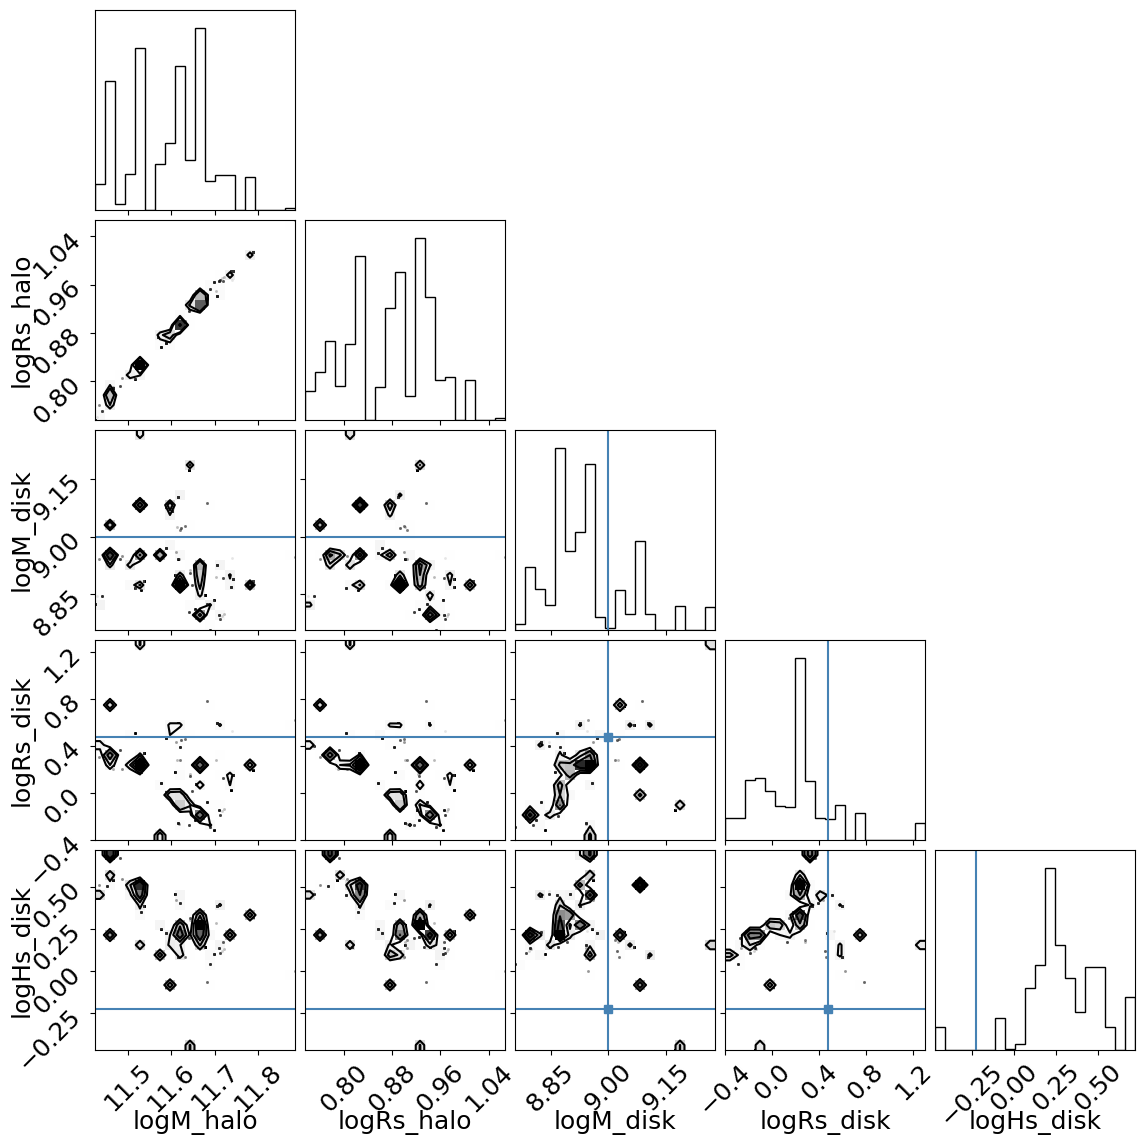

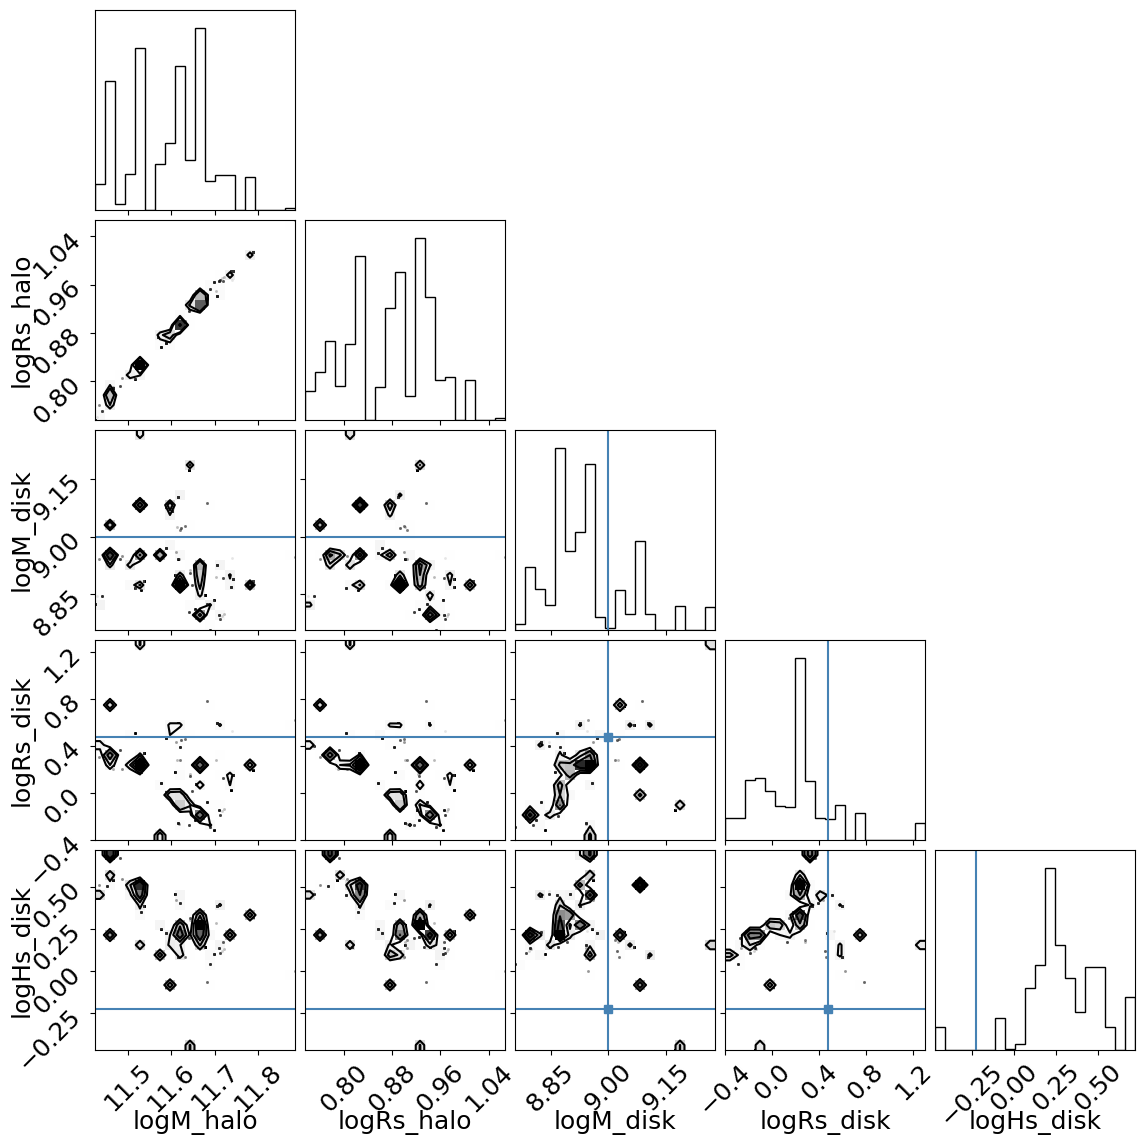

In [ ]:
import pandas as pd


param_names = ['logM_halo', 'logRs_halo', 'logM_disk', 'logRs_disk', 'logHs_disk']

with open('/content/drive/MyDrive/SchwarMAX/axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)

ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item(),
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}


# samples_plot = samples
samples_plot = pd.read_csv('/content/drive/MyDrive/SchwarMAX/first_fake_posterior.csv').to_numpy()
ground_truth_plot = [ground_truth[k] for k in param_names]
corner.corner(samples_plot, labels=param_names, truths=ground_truth_plot)